# Applied Data Science with Python: Marketing Campaigns EDA & Hypothesis Testing

## Course-End Project Problem Statement

This notebook performs exploratory data analysis (EDA) and hypothesis testing on marketing campaign data, focusing on customer acquisition factors. The analysis covers the four Ps of marketing: People, Product, Place, and Promotion.

### Outline
1. Import Libraries and Load Data
2. Investigate Data Types and Initial Data Cleaning
3. Missing Value Imputation for Income
4. Create Derived Variables: Total Children, Age, Total Spending, Total Purchases
5. Visualize Distributions: Box Plots and Histograms
6. Outlier Detection and Treatment
7. Categorical Variable Encoding: Ordinal and One-Hot
8. Correlation Analysis with Heatmap
9. Hypothesis Testing
10. Product Revenue Analysis
11. Age vs. Last Campaign Acceptance Rate Visualization
12. Country-wise Last Campaign Acceptance Visualization
13. Children at Home vs. Total Spend Analysis
14. Education Background of Customers Who Complained

In [28]:
# 1. Import Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r'data_scince/marketing_data.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [29]:
# 2. Investigate Data Types and Initial Data Cleaning
print(df.info())
print(df.describe(include='all'))

# Check unique values in education and marital status
print('Education:', df['Education'].unique())
print('Marital_Status:', df['Marital_Status'].unique())

# Clean education and marital status categories (strip spaces, unify similar labels)
df['Education'] = df['Education'].str.strip().replace({'PhD': 'Doctorate', 'Master': 'Masters', 'Graduation': 'Graduate'})
df['Marital_Status'] = df['Marital_Status'].str.strip().replace({'Together': 'Married', 'Divorced': 'Single', 'Widow': 'Single'})

# Convert Dt_Customer to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4   Income               2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

C:\Users\Avnish\AppData\Local\Temp\ipykernel_28852\1651233681.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduate,Single,"$84,835.00",0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduate,Single,"$57,091.00",0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduate,Married,"$67,267.00",0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduate,Married,"$32,474.00",1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduate,Single,"$21,474.00",1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [30]:
# 3. Missing Value Imputation for Income

# Clean column names by stripping spaces
df.columns = df.columns.str.strip()

# Ensure 'Income' is numeric
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

# Impute missing income values by group mean (education + marital status)
income_impute = df.groupby(['Education', 'Marital_Status'])['Income'].transform('mean')
df['Income'] = df['Income'].fillna(income_impute)
print('Missing Income values after imputation:', df['Income'].isna().sum())
df.head()

Missing Income values after imputation: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduate,Single,NaN,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduate,Single,NaN,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduate,Married,NaN,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduate,Married,NaN,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduate,Single,NaN,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [31]:
# 4. Create Derived Variables: Total Children, Age, Total Spending, Total Purchases
from datetime import datetime

# Total children
if 'Kidhome' in df.columns and 'Teenhome' in df.columns:
    df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Age
current_year = datetime.now().year
if 'Year_Birth' in df.columns:
    df['Age'] = current_year - df['Year_Birth']

# Total spending (sum of product columns)
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[product_cols].sum(axis=1)

# Total purchases (sum of purchase channels)
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_Children,Age,Total_Spending,Total_Purchases
0,1826,1970,Graduate,Single,NaN,0,0,2014-06-16,0,189,...,0,0,0,1,0,SP,0,55,1190,14
1,1,1961,Graduate,Single,NaN,0,0,2014-06-15,0,464,...,0,0,1,1,0,CA,0,64,577,17
2,10476,1958,Graduate,Married,NaN,0,1,2014-05-13,0,134,...,0,0,0,0,0,US,1,67,251,10
3,1386,1967,Graduate,Married,NaN,1,1,2014-05-11,0,10,...,0,0,0,0,0,AUS,2,58,11,3
4,5371,1989,Graduate,Single,NaN,1,0,2014-04-08,0,6,...,0,0,0,1,0,SP,1,36,91,6


ValueError: List of boxplot statistics and `positions` values must have same the length

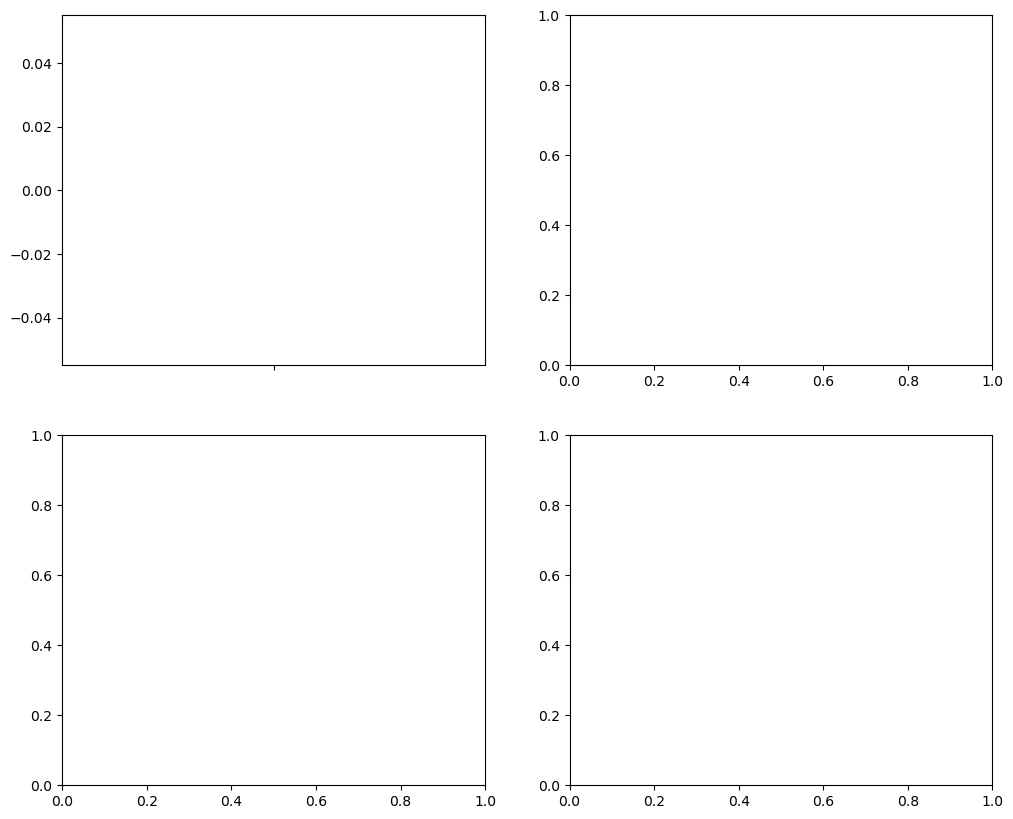

In [32]:
# 5. Visualize Distributions: Box Plots and Histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(data=df, y='Income', ax=axes[0,0])
sns.histplot(df['Income'], kde=True, ax=axes[0,1])
sns.boxplot(data=df, y='Total_Spending', ax=axes[1,0])
sns.histplot(df['Total_Spending'], kde=True, ax=axes[1,1])
plt.tight_layout()
plt.show()

In [ ]:
# 6. Outlier Detection and Treatment
# Example: Capping outliers in Income and Total_Spending using IQR
for col in ['Income', 'Total_Spending']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

# Visualize after treatment
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, y='Income', ax=axes[0])
sns.boxplot(data=df, y='Total_Spending', ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
# 7. Categorical Variable Encoding: Ordinal and One-Hot
from sklearn.preprocessing import OrdinalEncoder

# Ordinal encoding for Education (ordered)
ordinal_edu = ['Basic', 'Graduate', 'Masters', 'Doctorate']
df['Education_Ordinal'] = OrdinalEncoder(categories=[ordinal_edu]).fit_transform(df[['Education']])

# One-hot encoding for Marital_Status and Country
one_hot_cols = ['Marital_Status', 'Country']
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)
df.head()

In [ ]:
# 8. Correlation Analysis with Heatmap
corr = df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# 9. Hypothesis Testing
import scipy.stats as stats

# Hypothesis 1: Older people prefer shopping in-store
sns.boxplot(x='Age', y='NumStorePurchases', data=df)
plt.title('Age vs. Store Purchases')
plt.show()
print(stats.pearsonr(df['Age'], df['NumStorePurchases']))

# Hypothesis 2: Customers with kids prefer online shopping
sns.boxplot(x='Total_Children', y='NumWebPurchases', data=df)
plt.title('Children at Home vs. Web Purchases')
plt.show()
print(stats.pearsonr(df['Total_Children'], df['NumWebPurchases']))

# Hypothesis 3: Channel cannibalization
sns.scatterplot(x='NumStorePurchases', y='NumWebPurchases', data=df)
plt.title('Store vs. Web Purchases')
plt.show()
print(stats.pearsonr(df['NumStorePurchases'], df['NumWebPurchases']))

# Hypothesis 4: US vs. rest of world in total purchases
us_purchases = df[df['Country_US'] == 1]['Total_Purchases']
rest_purchases = df[df['Country_US'] == 0]['Total_Purchases']
print(stats.ttest_ind(us_purchases, rest_purchases, nan_policy='omit'))

In [ ]:
# 10. Product Revenue Analysis
product_revenue = df[product_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=product_revenue.index, y=product_revenue.values)
plt.title('Product Revenue Comparison')
plt.ylabel('Total Revenue')
plt.xlabel('Product')
plt.show()
print('Best performing product:', product_revenue.idxmax())
print('Least performing product:', product_revenue.idxmin())

In [ ]:
# 11. Age vs. Last Campaign Acceptance Rate Visualization
if 'Response' in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Response', y='Age', data=df)
    plt.title('Age vs. Last Campaign Acceptance')
    plt.show()
    print(df.groupby('Response')['Age'].mean())

In [ ]:
# 12. Country-wise Last Campaign Acceptance Visualization
if 'Response' in df.columns and 'Country' in df.columns:
    country_accept = df[df['Response'] == 1]['Country'].value_counts()
    plt.figure(figsize=(10,6))
    sns.barplot(x=country_accept.index, y=country_accept.values)
    plt.title('Country-wise Last Campaign Acceptance')
    plt.ylabel('Number of Acceptances')
    plt.xlabel('Country')
    plt.show()
    print('Country with most acceptances:', country_accept.idxmax())

In [ ]:
# 13. Children at Home vs. Total Spend Analysis
plt.figure(figsize=(8,5))
sns.boxplot(x='Total_Children', y='Total_Spending', data=df)
plt.title('Children at Home vs. Total Spending')
plt.show()
print(df.groupby('Total_Children')['Total_Spending'].mean())

In [ ]:
# 14. Education Background of Customers Who Complained
if 'Complain' in df.columns:
    edu_complain = df[df['Complain'] == 1]['Education'].value_counts()
    plt.figure(figsize=(8,5))
    sns.barplot(x=edu_complain.index, y=edu_complain.values)
    plt.title('Education Background of Customers Who Complained')
    plt.ylabel('Number of Complaints')
    plt.xlabel('Education')
    plt.show()
    print(edu_complain)

# Applied Data Science with Python: Marketing Campaigns Project
 
## Project Overview
This project explores the impact of the marketing mix (Product, Price, Place, Promotion) on customer acquisition using real-world data. The analysis covers demographic, product, channel, and campaign variables.
 
### Objectives
- Perform exploratory data analysis (EDA) and hypothesis testing to understand customer acquisition drivers.
- Clean and preprocess data, including missing value imputation for income based on education and marital status.
- Engineer features: total children, age, total spending, and total purchases.
- Visualize distributions, detect and treat outliers.
- Encode categorical variables using ordinal and one-hot encoding.
- Analyze correlations with a heatmap.
- Test hypotheses about shopping preferences, channel cannibalization, and country performance.
- Visualize product revenue, campaign acceptance, and complaint patterns.
 
### Steps
1. Import and inspect data (Dt_Customer, Income, etc.)
2. Impute missing income values by education and marital status groups
3. Create derived variables: total children, age, total spending, total purchases
4. Visualize distributions and treat outliers
5. Encode categorical variables
6. Correlation analysis with heatmap
7. Hypothesis testing:
   - Age vs. store preference
   - Children vs. online shopping
   - Channel cannibalization
   - US vs. rest of world purchases
8. Visualize:
   - Best/worst products by revenue
   - Age vs. campaign acceptance
   - Country-wise campaign acceptance
   - Children at home vs. total spend
   - Education of customers who complained